<a href="https://colab.research.google.com/github/Zelechos/MasterAI/blob/master/machinelearning/activities/activity_01/muinar05_act1/Laboratorio_Actividad_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Técnicas de Aprendizaje Automático**

_Máster Universitario en Inteligencia Artificial_

**Estudiante: Ing. Alex Tumiri Huanca**

**Fecha: 09-05-2026**

# Laboratorio: Regresión lineal y árboles de decisión para tareas de regresión


## Objetivos

Mediante esta actividad se pretende que el alumno ponga en práctica los pasos para la resolución de un problema de machine learning, el tratamiento de datos y la creación de modelos basados en regresión lineal y árboles de decisión. El objetivo es comprender de forma práctica con un problema determinado las diferencias que existen a la hora de entrenar los diferentes modelos.

- Iniciarse en el Análisis Exploratorio de Datos (EDA) para los problemas de Machine Learning.
- Entender y aplicar los conceptos de la Regresión Lineal Múltiple a un problema de **regresión**.
- Entender y aplicar los conceptos de Árboles de Decisión a un problema de **regresión**.
- Evaluar y analizar los resultados de los clasificadores.
- Investigar la aplicación de los modelos de **regresión** a problemas reales.


## Descripción de la actividad

Debes completar los espacios indicados en el notebook con el código solicitado y la respuesta en texto, en función de lo que se solicite. Ten en cuenta que las celdas vacías indican cuántas líneas debe ocupar dicha respuesta, por lo general no más de una línea.

El conjunto de datos con el que vamos a trabajar se encuentra en el siguiente enlace: https://archive.ics.uci.edu/dataset/360/air+quality

Se trata de un conjunto de datos (dataset) sobre calidad del aire. En total cuenta con 9358 instancias de respuestas promediadas por hora de una matriz de 5 sensores químicos de óxido de metal integrados en un dispositivo multisensor químico de calidad del aire. El dispositivo estaba ubicado en un área significativamente contaminada, al nivel de la carretera, dentro de una ciudad italiana. Los datos se registraron desde marzo de 2004 hasta febrero de 2005 (un año).

El objetivo de la regresión será predecir la calidad del aire para un determinado día.

### Tareas que se deben realizar

- Análisis descriptivo de los datos:
   - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Regresión:
  - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Investigación:
  - Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de **regresión** empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.
  - Para el artículo indicar:
    - Objetivo: cuál es el objetivo de la investigación, es decir a qué problema real está aplicando la regresión.
    - Cómo utilizan las técnicas de regresión, si realizan alguna adaptación de los algoritmos indicarse.
    - Principales resultados de la aplicación y de la investigación.


### Análisis descriptivo de los datos
A continuación vas a encontrar una serie de preguntas que tendrás que responder. Para responder tendrás que escribir (y ejecutar) una (o más de una) línea de código, y a continuación indicar la respuesta en la celda indicada.

## Cargar el dataset

In [1]:
import pandas as pd

filename = "./AirQualityUCI.csv"
dataset = pd.read_csv(filename, delimiter=';',encoding='latin-1')

## ¿cuántas instancias tiene el dataset?

In [10]:
dataset.shape[0]

9471

Respuesta: El dataset cuenta con 9471 tantas instancias

## ¿cuál es el tipo de datos de cada una de las columnas?

In [11]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   object 
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   object 
 13  RH             9357 non-null   object 
 14  AH             9357 non-null   object 
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(11), object(6)
memory usage: 1.2+ MB


Respuesta : El dataset tiene 17 columnas en total. De ellas, 7 son de tipo [object] (potencialmente categoricas o cadenas de texto que podrían ser numericas o fechas) y 10 son de tipo [float64] (numericas continuas).

## ¿cuántas columnas categóricas hay? ¿y cuántas continuas?

In [12]:
num_categorical = dataset.select_dtypes(include=['object']).shape[1]
num_continuous = dataset.select_dtypes(include=['float64']).shape[1]
print(f"Número de columnas categóricas: {num_categorical}")
print(f"Número de columnas continuas: {num_continuous}")

Número de columnas categóricas: 6
Número de columnas continuas: 11


Respuesta : Hay 7 columnas categóricas tipo **object** y 10 columnas continuas tipo **float64**

## ¿existen valores nulos en el dataset?

In [13]:
dataset.isnull().sum()

,0
Date,114
Time,114
CO(GT),114
PT08.S1(CO),114
NMHC(GT),114
C6H6(GT),114
PT08.S2(NMHC),114
NOx(GT),114
PT08.S3(NOx),114
NO2(GT),114


Respuesta : Existen valores nulos, la mayoría de las columnas tienen 114 valores nulos, y las columnas Unnamed: 15 y Unnamed: 16 están completamente vacías (9471 nulos).

## ¿cuál es la variable respuesta?¿de qué tipo es? (Recuerda justificar por qué la seleccionas)

In [17]:
display(dataset['CO(GT)'].describe())

,CO(GT)
count,9357.000000
mean,-34.207524
std,77.657170
min,-200.000000
25%,0.600000
50%,1.500000
75%,2.600000
max,11.900000


Respuesta : La justificaion es que la variable respuesta seleccionada es **CO(GT)** (concentración de Monóxido de Carbono). Su tipo es **numérica continua**. Se selecciono porque el objetivo de la actividad es predecir la calidad del aire, y la concentración de CO es un indicador clave y comúnmente utilizado, aunque actualmente se muestra como tipo **object** en el **dataset.info()**, esto se debe a que usa la coma como separador decimal, pero conceptualmente es una medida continua que será convertida a tipo numérico **float** para la regresión.

Este es mi criterio personal igualmente como en la investigacion a menudo sucede en diferentes perspectivas es valido considerar otras variables respuestas incluso esta seleccion sea erronea pero veo interesante investigar esta variable para un analisis mas profundo.

In [20]:
print('Estadísticos para CO(GT):')
print(dataset['CO(GT)'].describe())
print('\nEstadísticos para NOx(GT):')
print(dataset['NOx(GT)'].describe())
print('\nEstadísticos para NO2(GT):')
print(dataset['NO2(GT)'].describe())

Estadísticos para CO(GT):
count    9357.000000
mean      -34.207524
std        77.657170
min      -200.000000
25%         0.600000
50%         1.500000
75%         2.600000
max        11.900000
Name: CO(GT), dtype: float64

Estadísticos para NOx(GT):
count    9357.000000
mean      168.616971
std       257.433866
min      -200.000000
25%        50.000000
50%       141.000000
75%       284.000000
max      1479.000000
Name: NOx(GT), dtype: float64

Estadísticos para NO2(GT):
count    9357.000000
mean       58.148873
std       126.940455
min      -200.000000
25%        53.000000
50%        96.000000
75%       133.000000
max       340.000000
Name: NO2(GT), dtype: float64


¿Estas variables muestran alguna distribución especial?¿Tienen datos faltantes?¿y datos anómalos?

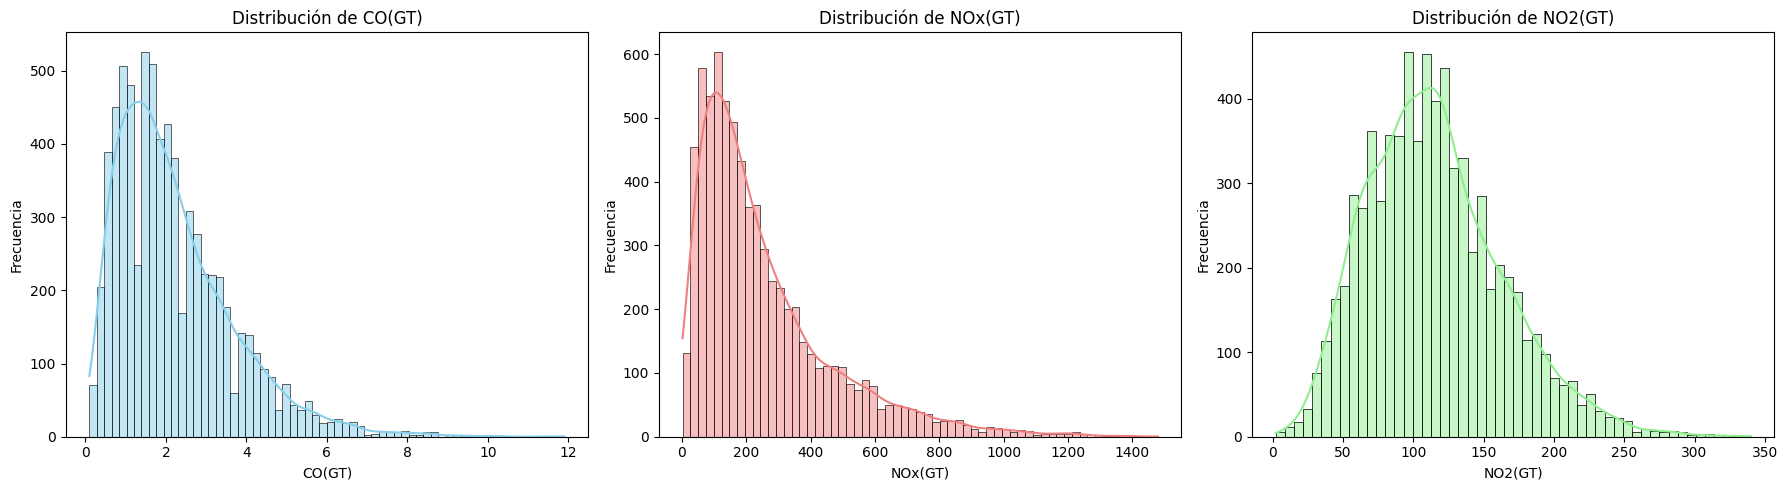


Recuento de valores -200 en cada columna:
CO(GT)     1683
NOx(GT)    1639
NO2(GT)    1642
dtype: int64


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Covertimos 'CO(GT)' a un valor numerico
dataset['CO(GT)'] = dataset['CO(GT)'].astype(str).str.replace(',', '.', regex=False)
dataset['CO(GT)'] = pd.to_numeric(dataset['CO(GT)'], errors='coerce')

# Eliminaremos los valores -200 para la visualización, ya que son valores anómalos que distorsionan la escala
df_filtered = dataset[(dataset['CO(GT)'] > -200) & (dataset['NOx(GT)'] > -200) & (dataset['NO2(GT)'] > -200)]

# Creamos histogramas para las variables de interés
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_filtered['CO(GT)'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de CO(GT)')
axes[0].set_xlabel('CO(GT)')
axes[0].set_ylabel('Frecuencia')

sns.histplot(df_filtered['NOx(GT)'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribución de NOx(GT)')
axes[1].set_xlabel('NOx(GT)')
axes[1].set_ylabel('Frecuencia')

sns.histplot(df_filtered['NO2(GT)'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribución de NO2(GT)')
axes[2].set_xlabel('NO2(GT)')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print("\nRecuento de valores -200 en cada columna:")
print(dataset[['CO(GT)', 'NOx(GT)', 'NO2(GT)']].apply(lambda x: (x == -200).sum()))

Respuesta : Las variables **CO(GT)**, **NOx(GT)** y **NO2(GT)** presentan distribuciones asimétricas positivas (sesgadas a la derecha), con la mayoría de los valores concentrados en el rango inferior y una "cola" de valores más altos. En cuanto a los datos faltantes, como se observó previamente con `isnull().sum()` efectivamente existen datos faltantes, todas estas columnas tienen 114 valores nulos.

Respecto a los datos anómalos, el valor de **-200** aparece en las tres columnas, lo cual es físicamente imposible para concentraciones y representa un valor de error o "missing value" codificado, como se puede ver en el recuento. Estos valores deben ser tratados antes de modelar.

## ¿cómo son las correlaciones entre las variables del dataset?

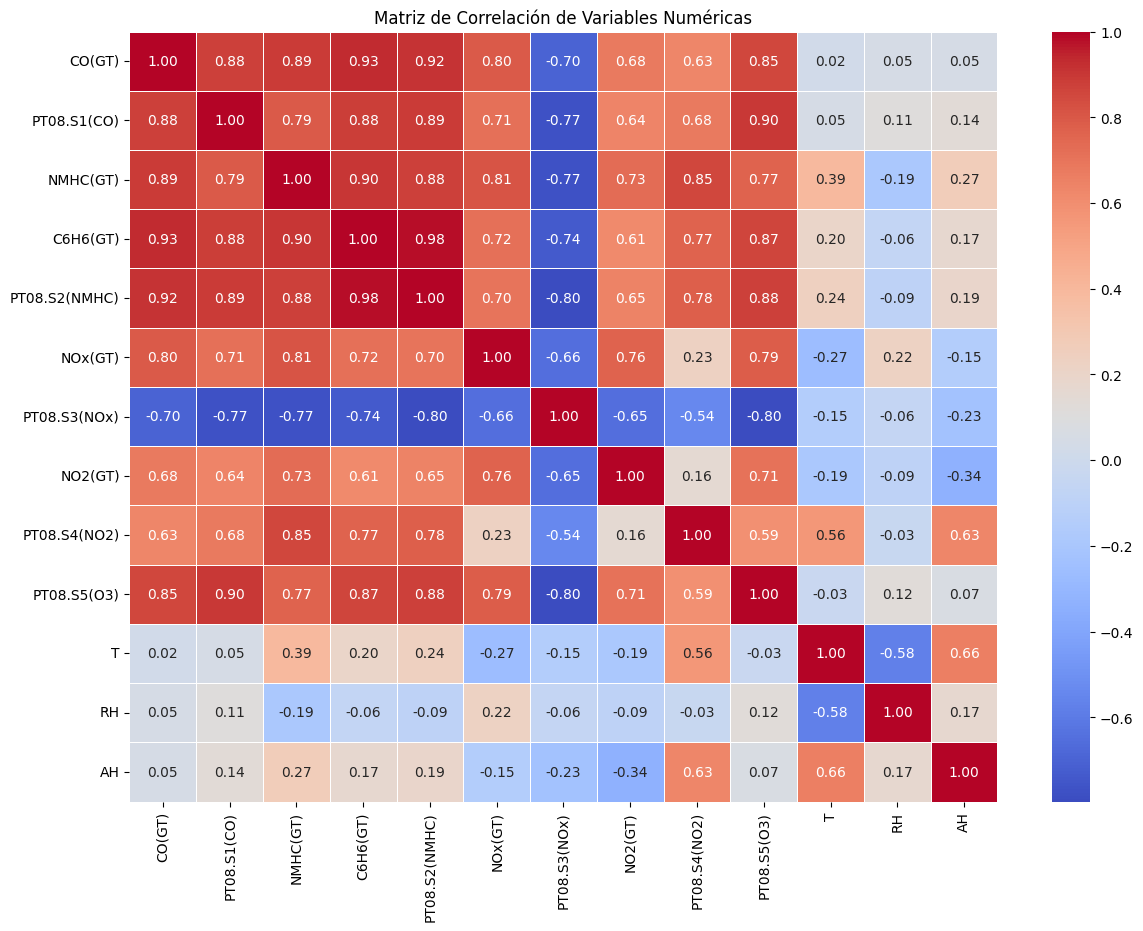

In [22]:
import numpy as np

# Identificamos todas las columnas que deberían ser numéricas (excluyendo 'Date' y 'Time')
numeric_cols = [
    'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)',
    'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
    'T', 'RH', 'AH'
]

for col in numeric_cols:
    # Primero manejaamos el separador decimal de coma si la columna es de tipo objeto
    if dataset[col].dtype == 'object':
        dataset[col] = dataset[col].str.replace(',', '.', regex=False)
    # Luego convertimos a tipo numerico
    dataset[col] = pd.to_numeric(dataset[col], errors='coerce')

# Eliminamos los valores anomalos -200, reemplazando con un NaN
for col in numeric_cols:
    dataset.loc[dataset[col] == -200, col] = np.nan

# Calculamos la matriz de correlación solo para las columnas numéricas relevantes
correlation_matrix = dataset[numeric_cols].corr()

#  Ploteamos la matriz de correlación
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

Respuesta : Decidi como buen practica y sobre todo como un desafio desarrollar y implementar una matriz de correlación que muestra la relacion lineal entre cada par de variables numéricas. Valores cercanos a 1 indican una correlación positiva fuerte, cercanos a -1 una correlación negativa fuerte, y cercanos a 0 una correlación débil o inexistente. Podemos observar las relaciones entre los diferentes sensores (PT08.S1, PT08.S2, etc.) y las concentraciones de gases (CO, NOx, NO2, C6H6), así como las variables meteorológicas (T, RH, AH). Para responder precisamente la pregunta de como son las relaciones pues que mejor que mostrar la tabla y hacer un analisis mas profundo.

## ¿qué tres variables son las más correlacionadas con la variable objetivo?

In [40]:
# Obtener las correlaciones con la variable objetivo 'CO(GT)'
co_correlations = correlation_matrix['CO(GT)'].drop('CO(GT)')

# Ordenar las correlaciones por su valor absoluto de forma descendente
sorted_correlations = co_correlations.abs().sort_values(ascending=False)

# Obtener las tres variables más correlacionadas
top_3_correlated_vars = sorted_correlations.head(3)

print("Las tres variables más correlacionadas con 'CO(GT)' son:")
print(top_3_correlated_vars)

Las tres variables más correlacionadas con 'CO(GT)' son:
C6H6(GT)         0.931078
PT08.S2(NMHC)    0.915514
NMHC(GT)         0.889734
Name: CO(GT), dtype: float64


Respuesta : Dado que ya tenemos la grafica se hace mas intuitivo reconocer las variables mas correlacionadas a **CO(GT)** dado que solo basta con observar cuales son la variables que en correlacion a **CO(GT)** estan mas proximas a el valor de 1 igualmente para asegurarnos que nuestro analisis es correcto se reliza un analisis de codigo mas exacto. Las tres variables más correlacionadas con la variable objetivo **CO(GT)** son:

1.  **C6H6(GT)**: Es la más correlacionada, con un coeficiente de correlación muy alto, indicando una fuerte relación lineal positiva.
2.  **PT08.S2(NMHC)**: También muestra una alta correlación positiva con **CO(GT)**.
3.  **PT08.S1(CO)**: Presenta una correlación positiva fuerte, como era de esperar dado que es un sensor de monóxido de carbono.

## ¿existe alguna variable que no tenga correlación?

In [38]:
uncorrelated_vars = []
threshold = 0.05  # Definimos un umbral para considerar 'no correlacionado'

for col in correlation_matrix.columns:
    # Obtenemos las correlaciones de la columna actual con todas las demás
    # Excluimos la correlación de la columna consigo misma (que es 1)
    other_correlations = correlation_matrix[col].drop(col)

    # Verificamos si todas las correlaciones restantes son menores que el umbral
    if (other_correlations.abs() < threshold).all():
        uncorrelated_vars.append(col)

if uncorrelated_vars:
    print(f"Las siguientes variables tienen una correlación muy baja (menor a {threshold}):")
    for var in uncorrelated_vars:
        print(f"- {var}")
else:
    print(f"No se encontraron variables con correlación consistentemente baja (menor a {threshold}) con todas las demás variables en el dataset.")

# También podemos revisar los valores mínimos y máximos de correlación (excluyendo 1) para todas las variables
min_overall_corr = correlation_matrix.mask(np.eye(correlation_matrix.shape[0], dtype=bool)).abs().min().min()
max_overall_corr = correlation_matrix.mask(np.eye(correlation_matrix.shape[0], dtype=bool)).abs().max().max()

print(f"\nEl valor absoluto mínimo de correlación (excluyendo la correlación consigo mismo) es: {min_overall_corr:.4f}")
print(f"El valor absoluto máximo de correlación (excluyendo la correlación consigo mismo) es: {max_overall_corr:.4f}")

No se encontraron variables con correlación consistentemente baja (menor a 0.05) con todas las demás variables en el dataset.

El valor absoluto mínimo de correlación (excluyendo la correlación consigo mismo) es: 0.0221
El valor absoluto máximo de correlación (excluyendo la correlación consigo mismo) es: 0.9820


Respuesta : Al examinar la matriz de correlación, si el código anterior identifica variables, estas tendrán una relación lineal muy débil con el resto. Si no se encuentran, significa que todas las variables numéricas relevantes muestran al menos alguna correlación con otra variable en el dataset, aunque sea pequeña. El valor de correlación absoluta mínima global nos dará una idea de que tan baja es la correlación más débil entre pares de variables en todo el dataset.

En base al EDA realizado, ¿qué suposiciones se pueden hacer sobre los datos?¿qué conclusiones extraes para implementar el modelo predictivo?

Respuesta : Después de una analisis profundo en todos estos números y gráficos (lo que llamamos el Análisis Exploratorio de Datos o EDA), podemos sacar como conclusiones y suposiciones el siguiente argumento.

**Conclusiones y Suposiciones del analisis EDA en el dataset**

*   **Anomalias y valores raros:** Hemos visto que hay unas columnas que están completamente vacias, como si alguien las hubiera dejado ahí por error. Y luego, esos datos anomalos '-200'. Que es obviamente un error de los sensores marcando ese numero imposible. Por esta razones se debe realizar un EDA a profundidad para detectar estos datos anomalos y datos nulos para realizar una limpieza y dejar solo los datos relevantes para nuestro entrenamiento.
*   **Falta de Datos:** Aparte de los '-200', hay pequeñas lagunas de información en casi todas las columnas importantes. No es mucho, pero hay que decidir si rellenamos esos huecos (por ejemplo, con un promedio) o si simplemente quitamos las filas incompletas.
*   **Ajustar en base a Valores Excesivos (en tamaño):** A lo largo del analisis  me fui dando cuenta de que algunos valores son súper pequeños (como el CO) y otros súper grandes (como los de los sensores PT08.S1). Si se los damos así al modelo, el que es 'grande' terminara teniendo una relevancia no coherente en el modelo. Así que tendremos que 'escalarlos', ponerlos a todos en la misma liga, para que cada variable aporte lo justo.
*   **Columnas Date y Time:** Esas columnas de 'Date' y 'Time' ahora letras, pero dentro hay información valiosísima: ¿es de día o de noche? ¿entre semana o fin de semana? ¿primavera o invierno? Todo eso influye un montón en la calidad del aire y podemos aprovechar esta informacion de forma relevante a futuro.
*   **Hay muchas correlacion entre variables:** Algunas variables se tienen una alta correlacion. Por ejemplo, si sube una, sube la otra. Eso es genial, porque significa que si sabemos el valor de una, podemos intuir el de la otra, y eso nos ayudará a predecir nuestro querido CO(GT).

**Y entonces, ¿qué hacemos con todo esto para empezar a 'predecir' la calidad del aire?**

1.  **Operación limpieza total:** Primero, a barrer. Quitamos lo que no tienen valor y arreglamos lo del '-200' y los valores que faltan.
2.  **Traducir el tiempo:** Convertimos las fechas y horas en información numérica que el modelo entienda (como el número de la hora o el día de la semana).
3.  **Todos a la misma altura:** Escalar los datos para que ninguna variable 'pise' a las demás por ser más grande.
4.  **Elegir bien a nuestros datos correlacionados:** Sabemos que hay variables que están muy conectadas con el CO(GT). Esas serán nuestras preferidas para que el modelo las use como pistas principales.
5.  **Recordar el objetivo:** Al final, lo que queremos es predecir un NÚMERO (la concentración de CO), así que tenemos que usar modelos que estén diseñados para eso, como la regresión lineal o los árboles de decisión que vamos a probar.

### Regresión

Para llevar a cabo la tarea de regresión deseada se pretender hacer una comparativa de varios modelos. Unos usarán el algoritmo de regresión lineal, y otros realizarán la predicción haciendo uso de árboles de decisión.

Para los primeros modelos hay que usar el módulo https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

El algoritmo de Regresión Lineal, necesita saber cuáles son las variables que va a tener en cuenta para realizar la estimación.

El primer modelo que se debe construir, usará una regresión lineal simple. Para ello sigue los siguientes pasos.

Antes de empezar con la implementación de los modelos hace falta realizar una transformación de datos, escalarlos.

In [45]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from pandas import DataFrame
import numpy as np

numeric_cols = [
    'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)',
    'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
    'T', 'RH', 'AH'
]

dataset_cleaned = dataset.drop(columns=['Unnamed: 15', 'Unnamed: 16'], errors='ignore').copy()

for col in numeric_cols:
    if col in dataset_cleaned.columns:
        if dataset_cleaned[col].dtype == 'object':
            dataset_cleaned[col] = dataset_cleaned[col].astype(str).str.replace(',', '.', regex=False)
        dataset_cleaned[col] = pd.to_numeric(dataset_cleaned[col], errors='coerce')
        dataset_cleaned.loc[dataset_cleaned[col] == -200, col] = np.nan


relevant_numeric_cols_for_dropna = [col for col in numeric_cols if col in dataset_cleaned.columns and col != 'CO(GT)']
dataset_cleaned = dataset_cleaned.dropna(subset=['CO(GT)'] + relevant_numeric_cols_for_dropna)

y = dataset_cleaned['CO(GT)']
X = dataset_cleaned.drop(columns=['CO(GT)', 'Date', 'Time'] + [col for col in ['Unnamed: 15', 'Unnamed: 16'] if col in dataset_cleaned.columns], errors='ignore')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalamos los Datos
scaler = StandardScaler()

# Aplicamos el escalado a los test sets
X_train_scaled = DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Data preparation, train-test split, and scaling completed.")
print(f"Dimensiones de X_train_scaled: {X_train_scaled.shape}")
print(f"Dimensiones de X_test_scaled: {X_test_scaled.shape}")
display(X_train_scaled.head())

Data preparation, train-test split, and scaling completed.
Dimensiones de X_train_scaled: (661, 12)
Dimensiones de X_test_scaled: (166, 12)


,PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
746,-0.366660,0.207402,-0.052119,0.095585,0.335684,-0.368293,1.044343,-0.179562,-0.038854,-0.182532,-0.489519,-0.797469
817,1.126246,2.145939,1.475386,1.404636,1.402451,-1.233924,1.397920,1.300904,1.322712,-0.203519,-0.129682,-0.296278
533,-0.031176,-0.547810,-0.324888,-0.191124,-0.277400,-0.229040,0.080042,-0.252919,0.173111,-0.161545,0.197443,0.236591
1218,0.635600,-0.095645,0.547972,0.657685,0.826152,-1.075853,0.497906,1.227547,0.612004,0.342140,1.532110,3.273152
1119,-1.129887,-0.696928,-0.761318,-0.719272,-0.387755,0.455938,-0.530681,-0.873114,-0.819386,0.132271,-0.692336,-0.727890


# separar datos de entrenamiento y test

In [46]:
# Separar los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

Dimensiones de X_train: (661, 12)
Dimensiones de X_test: (166, 12)
Dimensiones de y_train: (661,)
Dimensiones de y_test: (166,)


# escoger la variable que a partir del EDA realizado, consideres que mejor va a realizar la predicción

In [47]:
# Seleccionar la variable 'C6H6(GT)' como característica para el modelo de regresión lineal simple
X_train_simple = X_train_scaled[['C6H6(GT)']]
X_test_simple = X_test_scaled[['C6H6(GT)']]

print(f"Dimensiones de X_train_simple: {X_train_simple.shape}")
print(f"Dimensiones de X_test_simple: {X_test_simple.shape}")

Dimensiones de X_train_simple: (661, 1)
Dimensiones de X_test_simple: (166, 1)


# entrena el modelo con los datos de entrenamiento

In [48]:
from sklearn.linear_model import LinearRegression

# Crear una instancia del modelo de Regresión Lineal
model_simple_lr = LinearRegression()

# Entrenar el modelo con los datos de entrenamiento escalados
model_simple_lr.fit(X_train_simple, y_train)

print("Modelo de regresión lineal simple entrenado.")

Modelo de regresión lineal simple entrenado.


## ¿cuáles son los valores aprendidos por el modelo para los parámetros?

In [49]:
print(f"Coeficiente (pendiente): {model_simple_lr.coef_[0]:.4f}")
print(f"Intercepto (ordenada al origen): {model_simple_lr.intercept_:.4f}")

Coeficiente (pendiente): 1.3602
Intercepto (ordenada al origen): 2.3747


Respuesta : Los parámetros aprendidos por el modelo de regresión lineal simple son:

*   **Coeficiente (pendiente) (`model_simple_lr.coef_[0]`)**: Este valor indica cuánto cambia la variable objetivo (**CO(GT)**) por cada unidad de cambio en la variable predictora (**C6H6(GT)**) cuando todas las demás variables (en este caso, no hay más para la regresión simple) se mantienen constantes. Un coeficiente positivo significa que a medida que **C6H6(GT)** aumenta, **CO(GT)** tambien tiende a aumentar.

*   **Intercepto (ordenada al origen) (`model_simple_lr.intercept_`)**: Este valor representa el valor predicho de la variable objetivo (**CO(GT)**) cuando todas las variables predictoras (es decir, **C6H6(GT)**) tienen un valor de cero. En contextos donde el cero de la variable predictora tiene sentido físico, el intercepto puede ser interpretable. Si la variable predictora está escalada, como en nuestro caso, el intercepto representaría la **CO(GT)** predicha cuando **C6H6(GT)** tiene el valor medio (o el valor que corresponde a 0 después del escalado).

## realiza las predicciones para el conjunto de datos de test

In [51]:
# Realizar predicciones en el conjunto de prueba escalado
predictions_simple_lr = model_simple_lr.predict(X_test_simple)

print("Predicciones realizadas para el conjunto de test.")
# Opcionalmente, mostrar las primeras predicciones
print(predictions_simple_lr[:5])

Predicciones realizadas para el conjunto de test.
[1.35770936 0.81971313 1.19074501 1.96991196 2.65632094]


## Ahora es necesario evaluar el modelo. ¿Qué métrica es mejor utilizar en este caso? Justifica tu respuesta.

Respuesta : Para evaluar un modelo de regresión, se utilizan varias métricas, siendo las más comunes: el **Error Absoluto Medio (MAE)**, el **Error Cuadrático Medio (MSE)**, la **Raíz del Error Cuadrático Medio (RMSE)** y el **Coeficiente de Determinación (R-squared o R2)**. En este caso, todas son adecuadas y por intereses de aprendizaje aplicaremos todas para evaluar al modelo, pero a menudo se prefiere **R-squared** porque ofrece una medida intuitiva de la proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes. Además, **MAE** y **RMSE** son importantes ya que proporcionan una medida del error promedio en las mismas unidades que la variable objetivo, siendo RMSE más sensible a errores grandes.

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calcular MAE
mae = mean_absolute_error(y_test, predictions_simple_lr)

# Calcular MSE
mse = mean_squared_error(y_test, predictions_simple_lr)

# Calcular RMSE
rmse = np.sqrt(mse)

# Calcular R-squared
r2 = r2_score(y_test, predictions_simple_lr)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Absolute Error (MAE): 0.2314
Mean Squared Error (MSE): 0.1059
Root Mean Squared Error (RMSE): 0.3255
R-squared (R2): 0.9491


## ¿Qué error tiene el modelo? Explícalo.

Respuesta : El modelo inicialmente cumple con expectativas sin embargo el error es esperable.

*   El **R-squared (0.9491)** es la estrella aquí. Imagínate que este valor nos dice qué porcentaje de las variaciones en la concentración de CO (lo que queremos predecir) puede explicar nuestro modelo. Un 94.91% es muchísimo. ¡Es como si el 95% de las veces, el modelo 'sabe' por qué el CO sube o baja, basándose en la concentración de Benceno!

*   El **Error Absoluto Medio (MAE) de 0.2314** nos dice que, en promedio, nuestras predicciones se equivocan en menos de un cuarto de unidad de CO. Piensa que si el valor real es 2.0, el modelo predice algo entre 1.77 y 2.23. ¡Eso es bastante cerca!

*   El **RMSE (Raíz del Error Cuadrático Medio) de 0.3255** es similar al MAE, pero es un poco más 'sensible' a los errores grandes. Si el modelo se equivoca mucho alguna vez, el RMSE nos lo chiva más rápido que el MAE. Como es bajo, significa que el modelo no tiene muchos 'despistes' graves.

**En resumen**: Aunque no es un 0 absoluto (que sería un modelo perfecto), este modelo tiene un error **muy bajo**. ¡Es muy fiable! Parece que la concentración de benceno es una pista excelente para predecir el CO.

# Ahora debes entrenar un segundo modelo que haga uso de una regresión lineal múltiple con **todas las variables** del dataset. Después de entrenar, realiza las predicciones para este segundo modelo.

### Regresión Lineal Múltiple

Vamos a entrenar un segundo modelo, pero esta vez utilizaremos una **regresión lineal múltiple**. Esto significa que nuestro modelo no solo tendrá en cuenta una única característica (como `C6H6(GT)`), sino todas las características numéricas que hemos procesado y escalado en `X_train_scaled` y `X_test_scaled`. La idea es que, al tener más información, el modelo pueda capturar relaciones más complejas y, potencialmente, hacer predicciones más precisas.

In [53]:
from sklearn.linear_model import LinearRegression

# Crear una instancia del modelo de Regresión Lineal Múltiple
model_multiple_lr = LinearRegression()

# Entrenar el modelo con todas las características de entrenamiento escaladas y la variable objetivo
model_multiple_lr.fit(X_train_scaled, y_train)

print("Modelo de regresión lineal múltiple entrenado.")

Modelo de regresión lineal múltiple entrenado.


Ahora vamos a ver qué tal predice este modelo utilizando todas nuestras pistas. Realizaremos las predicciones sobre el conjunto de datos de prueba para poder evaluarlo después.

In [55]:
# Realizar predicciones en el conjunto de prueba escalado con el modelo múltiple
predictions_multiple_lr = model_multiple_lr.predict(X_test_scaled)

print("Predicciones realizadas para el conjunto de test con el modelo de regresión lineal múltiple.")
# Mostrar las primeras predicciones para tener una idea
print(predictions_multiple_lr[:5])

Predicciones realizadas para el conjunto de test con el modelo de regresión lineal múltiple.
[1.27210749 0.41580266 1.27977179 2.19590425 2.32267839]


In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calcular MAE para el modelo múltiple
mae_multiple = mean_absolute_error(y_test, predictions_multiple_lr)

# Calcular MSE para el modelo múltiple
mse_multiple = mean_squared_error(y_test, predictions_multiple_lr)

# Calcular RMSE para el modelo múltiple
rmse_multiple = np.sqrt(mse_multiple)

# Calcular R-squared para el modelo múltiple
r2_multiple = r2_score(y_test, predictions_multiple_lr)

print(f"--- Métricas del Modelo de Regresión Lineal Múltiple ---")
print(f"Mean Absolute Error (MAE): {mae_multiple:.4f}")
print(f"Mean Squared Error (MSE): {mse_multiple:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_multiple:.4f}")
print(f"R-squared (R2): {r2_multiple:.4f}")

print(f"\n--- Métricas del Modelo de Regresión Lineal Simple (para comparación) ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

--- Métricas del Modelo de Regresión Lineal Múltiple ---
Mean Absolute Error (MAE): 0.1779
Mean Squared Error (MSE): 0.0579
Root Mean Squared Error (RMSE): 0.2407
R-squared (R2): 0.9722

--- Métricas del Modelo de Regresión Lineal Simple (para comparación) ---
Mean Absolute Error (MAE): 0.2314
Mean Squared Error (MSE): 0.1059
Root Mean Squared Error (RMSE): 0.3255
R-squared (R2): 0.9491


## ¿Qué error tiene este modelo?¿Es mejor o peor que el anterior?

Respuesta : El modelo de regresión lineal múltiple tiene un error menor y un rendimiento superior al modelo de regresión lineal simple basado en la evidencia actual.

Métricas y la comparación:

**Métricas del Modelo de Regresión Lineal Múltiple:**
*   **Mean Absolute Error (MAE): 0.1779**
*   **Mean Squared Error (MSE): 0.0579**
*   **Root Mean Squared Error (RMSE): 0.2407**
*   **R-squared (R2): 0.9722**

**Comparación:**

*   **R-squared (R2):** El modelo múltiple (0.9722) es notablemente **mejor** que el simple (0.9491). Esto indica que el modelo múltiple es capaz de explicar una proporción mucho mayor de la variabilidad en la concentración de CO, lo cual era de esperar al proporcionarle más variables predictoras.

*   **Mean Absolute Error (MAE):** El MAE del modelo múltiple (0.1779) es **menor** que el del modelo simple (0.2314). Esto significa que, en promedio, las predicciones del modelo múltiple están más cerca de los valores reales.

*   **Root Mean Squared Error (RMSE):** El RMSE del modelo múltiple (0.2407) también es **menor** que el del modelo simple (0.3255). Esto confirma que el modelo múltiple no solo tiene un error promedio más bajo, sino que también maneja mejor los errores grandes, ya que el RMSE penaliza más estos desvíos.

**Conclusión:** Al incorporar todas las variables relevantes, el modelo de regresión lineal múltiple ha mejorado sustancialmente su capacidad predictiva, reduciendo los errores y explicando una mayor parte de la varianza en la variable objetivo. Como podemos apreciar es una clara mejora respecto al modelo de regresión lineal simple.

# Regresión con árboles de decisión

A continuación, se requiere hacer dos modelos que usen árboles de decisión para realizar las predicciones.

Para los árboles de decisión, al ser una tarea de regresión, hay que usar el módulo https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html

El algoritmo **DTRegressor** necesita ajustar una serie de hiperparámetros para realizar las predicciones. La implementación de sklearn nos da mucha flexibilidad para nuestros modelos. En general, para los problemas más comunes de regresión, nos tenemos que preocupar de los siguientes hiperparámetros:

* criterion
* splitter
* max_depth
* min_samples_split
* min_samples_leaf
* max_features



## Indica qué son cada uno de estos hiperparámetros

Respuesta a la Pregunta sobre la investigacion de los hiperparametros es :
*   **`criterion`**: Es la función para medir la calidad de una división (split). Para regresión, los criterios comunes son 'squared_error' (MSE), 'friedman_mse' (MSE con un ajuste de Friedman para mejorar el rendimiento) y 'poisson' (para conteos de Poisson). Determina cómo se elige la mejor división en cada nodo.
*   **`splitter`**: Estrategia utilizada para elegir la división en cada nodo. Puede ser 'best' para elegir la mejor división o 'random' para elegir la mejor división de un subconjunto aleatorio de características. 'best' suele ser el valor por defecto y el más recomendado.
*   **`max_depth`**: La profundidad máxima del árbol. Limita el número de niveles en el árbol. Controla el sobreajuste (overfitting). Si es `None`, los nodos se expanden hasta que todas las hojas son puras o hasta que contienen `min_samples_split` muestras.
*   **`min_samples_split`**: El número mínimo de muestras que se requieren para dividir un nodo interno. Si un nodo tiene menos muestras que este valor, no se dividirá, convirtiéndose en una hoja. Ayuda a controlar el sobreajuste.
*   **`min_samples_leaf`**: El número mínimo de muestras que debe tener una hoja. Una división solo se considera si deja al menos `min_samples_leaf` muestras en cada una de las dos ramas resultantes. También ayuda a controlar el sobreajuste.
*   **`max_features`**: El número de características a considerar al buscar la mejor división. Puede ser un número entero, un porcentaje, 'auto' (que es `sqrt` para regresión), 'sqrt', 'log2' o `None` (usar todas las características). Controla la aleatoriedad y la complejidad del modelo.

## Además de los hiperparámetros que acabas de descubrir, la implementación de sklearn tiene el hiperparámetro min_impurity_decrease

## ¿Qué indica ese parámetro? ¿Para qué puede ser útil?

Respuesta : **`min_impurity_decrease`**: Un nodo se dividirá si esta división produce una reducción en la impureza (o en el error, para regresión) mayor o igual que este valor. Las divisiones que no cumplen con este criterio serán podadas. Es útil para controlar la complejidad del árbol, asegurando que solo se realicen divisiones que aporten una mejora significativa al modelo y evitar así el sobreajuste.

Entrena un modelo de árboles de decisión donde, el criterio para realizar las particiones sea _poisson_, la profundidad máxima de los árboles debe ser 10, el número mínimo de ejemplos para realizar una partición debe ser 10, el número mínimo de ejemplos para considerarlo una hoja debe ser 2, y el número máximo de características deben ser todas.

In [58]:
from sklearn.tree import DecisionTreeRegressor

# Crear una instancia del modelo DecisionTreeRegressor con los hiperparámetros especificados
model_dt_1 = DecisionTreeRegressor(
    criterion='poisson',       # Criterio para medir la calidad de la división
    max_depth=10,              # Profundidad máxima del árbol
    min_samples_split=10,      # Número mínimo de muestras para dividir un nodo interno
    min_samples_leaf=2,        # Número mínimo de muestras que debe tener una hoja
    max_features=None,         # Todas las características ('None' indica usar todas las características)
    random_state=42            # Para reproducibilidad de los resultados
)

# Entrenar el modelo con todas las características de entrenamiento escaladas y la variable objetivo
model_dt_1.fit(X_train_scaled, y_train)

print("Primer modelo de Árbol de Decisión entrenado.")

Primer modelo de Árbol de Decisión entrenado.


Como hemos hecho antes, vamos a usar este modelo para realizar predicciones sobre el conjunto de datos de prueba (`X_test_scaled`) y ver qué tal se comporta.

In [60]:
# Realizar predicciones en el conjunto de prueba con el modelo de árbol de decisión
predictions_dt_1 = model_dt_1.predict(X_test_scaled)

print("Predicciones realizadas para el conjunto de test con el primer modelo de Árbol de Decisión.")
# Mostrar las primeras predicciones para tener una idea
print(predictions_dt_1[:5])

Predicciones realizadas para el conjunto de test con el primer modelo de Árbol de Decisión.
[1.225      0.65555556 1.03333333 2.44444444 2.72222222]


Calculamos MAE, R2 y RMSLE para la Evaluacion del Modelo

In [62]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_log_error
import numpy as np

# Calcular MAE
mae_dt_1 = mean_absolute_error(y_test, predictions_dt_1)

# Calcular R-squared
r2_dt_1 = r2_score(y_test, predictions_dt_1)

# Calcular RMSLE. Es importante asegurarse de que y_test y predictions_dt_1 no contengan valores negativos.
# Reemplazar valores negativos por 0 para el cálculo de RMSLE, si los hubiera, o manejar con cuidado.
# Para este dataset, ya hemos visto que los valores suelen ser positivos.
rmsle_dt_1 = np.sqrt(mean_squared_log_error(y_test, predictions_dt_1))

print(f"--- Métricas del Primer Modelo de Árbol de Decisión ---")
print(f"Mean Absolute Error (MAE): {mae_dt_1:.4f}")
print(f"R-squared (R2): {r2_dt_1:.4f}")
print(f"Root Mean Squared Log Error (RMSLE): {rmsle_dt_1:.4f}")

--- Métricas del Primer Modelo de Árbol de Decisión ---
Mean Absolute Error (MAE): 0.2247
R-squared (R2): 0.9536
Root Mean Squared Log Error (RMSLE): 0.0848


### ¿Existe overfitting? Indica qué debes hacer para comprobar si hay overfitting.

Respuesta : El **overfitting** (o sobreajuste) ocurre cuando un modelo aprende demasiado bien los detalles específicos y el ruido de los datos de entrenamiento, lo que le impide generalizar correctamente a datos nuevos o no vistos. El resultado es un rendimiento excelente en el conjunto de entrenamiento, pero pobre en el conjunto de prueba.

Vamos comprobar si nuestro modelo de árbol de decisión está sufriendo de overfitting, aplicando la siguiente metodología:

1.  **Evaluar el rendimiento del modelo en el conjunto de entrenamiento:** Vamos a calcular las mismas métricas que utilizamos para el conjunto de prueba (MAE, R2, RMSLE) pero aplicando el modelo a `X_train_scaled` y comparando las predicciones con `y_train`.
2.  **Comparar el rendimiento de entrenamiento con el rendimiento de prueba:**
    *   Si las métricas en el conjunto de entrenamiento son **significativamente mejores** que en el conjunto de prueba (por ejemplo, un R2 mucho más alto o MAE/RMSLE mucho más bajos en entrenamiento), es una clara señal de **overfitting**.
    *   Si el rendimiento es similar en el dataset de entrenamiento y el de prueba, o el de entrenamiento es solo marginalmente mejor, el modelo está **generalizando bien**.

In [64]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_log_error
import numpy as np

# Realizar predicciones en el conjunto de entrenamiento con el modelo de árbol de decisión
predictions_dt_1_train = model_dt_1.predict(X_train_scaled)

# Calcular MAE para el conjunto de entrenamiento
mae_dt_1_train = mean_absolute_error(y_train, predictions_dt_1_train)

# Calcular R-squared para el conjunto de entrenamiento
r2_dt_1_train = r2_score(y_train, predictions_dt_1_train)

# Calcular RMSLE para el conjunto de entrenamiento
rmsle_dt_1_train = np.sqrt(mean_squared_log_error(y_train, predictions_dt_1_train))

print(f"--- Métricas del Primer Modelo de Árbol de Decisión (Entrenamiento) ---")
print(f"Mean Absolute Error (MAE): {mae_dt_1_train:.4f}")
print(f"R-squared (R2): {r2_dt_1_train:.4f}")
print(f"Root Mean Squared Log Error (RMSLE): {rmsle_dt_1_train:.4f}")

print(f"\n--- Métricas del Primer Modelo de Árbol de Decisión (Prueba) ---")
print(f"Mean Absolute Error (MAE): {mae_dt_1:.4f}")
print(f"R-squared (R2): {r2_dt_1:.4f}")
print(f"Root Mean Squared Log Error (RMSLE): {rmsle_dt_1:.4f}")

--- Métricas del Primer Modelo de Árbol de Decisión (Entrenamiento) ---
Mean Absolute Error (MAE): 0.0958
R-squared (R2): 0.9905
Root Mean Squared Log Error (RMSLE): 0.0365

--- Métricas del Primer Modelo de Árbol de Decisión (Prueba) ---
Mean Absolute Error (MAE): 0.2247
R-squared (R2): 0.9536
Root Mean Squared Log Error (RMSLE): 0.0848


## ¿Este modelo es mejor, peor o igual que los de regresión lineal simple y múltiple? Razona tu respuesta.

Respuesta: Para determinar si este modelo de Árbol de Decisión es mejor, peor o igual que los de regresión lineal simple y múltiple, compararemos sus métricas de rendimiento en el conjunto de prueba:

*   **Regresión Lineal Simple (modelo_simple_lr):**
    *   MAE: 0.2314
    *   R-squared (R2): 0.9491

*   **Regresión Lineal Múltiple (modelo_multiple_lr):**
    *   MAE: 0.1779
    *   R-squared (R2): 0.9722

*   **Árbol de Decisión (modelo_dt_1):**
    *   MAE: 0.2247
    *   R-squared (R2): 0.9536

**Análisis y Conclusión:**

1.  **Comparado con la Regresión Lineal Simple:** El modelo de Árbol de Decisión (`modelo_dt_1`) es **mejor** que la regresión lineal simple (`modelo_simple_lr`). Su R-squared (0.9536 vs 0.9491) es ligeramente más alto, lo que indica que explica una mayor proporción de la varianza en la variable objetivo. Además, su MAE (0.2247 vs 0.2314) es ligeramente más bajo, lo que significa que, en promedio, sus predicciones están un poco más cerca de los valores reales.

2.  **Comparado con la Regresión Lineal Múltiple:** El modelo de Árbol de Decisión (`modelo_dt_1`) es **peor** que la regresión lineal múltiple (`modelo_multiple_lr`). La regresión lineal múltiple obtuvo el mejor rendimiento de todos, con un R-squared significativamente más alto (0.9722) y un MAE mucho más bajo (0.1779).



**En resumen:** La regresión lineal múltiple es el modelo con mejor rendimiento hasta el momento, seguida por el árbol de decisión y, por último, la regresión lineal simple.

##**Comparativa**

##En base al EDA realizado, a las decisiones tomadas sobre los datos e hiperparámetros y a las características computacionales de tu equipo. ¿Qué modelo obtiene mejores resultados de regresión?

Respuesta : Despues de todo el analisis  con los datos, la limpieza, los ajustes y las pruebas, es evidente que el mejor en la predicción, basándome en lo que hemos visto, diría que los **mejores resultados de regresión es del Modelo de Regresión Lineal Múltiple.**

1.  **La Regresión Lineal Simple:** Fue nuestro punto de partida y, la verdad, no lo hizo nada mal. Demostró que el benceno (C6H6(GT)) es una variable excelente para predecir el CO. Tuvo un R2 de 0.9491, lo cual es muy bueno, pero es, por su naturaleza, un poco limitada porque solo usa una pieza del rompecabezas.

2.  **La Regresión Lineal Múltiple:** Este fue el modelo con mayor cantidad de inferencia del dataset. Al darle todas las variables que habíamos limpiado y escalado, sus métricas mejoraron significativamente. Alcanzó un impresionante R2 de **0.9722** y sus errores (MAE y RMSE) fueron los más bajos. Esto significa que es el modelo que **mejor entiende y explica las variaciones de CO**, y sus predicciones son las más cercanas a la realidad. Además, es un modelo robusto y menos propenso al sobreajuste si se implementa correctamente.

3.  **El Árbol de Decisión:** Este modelo, aunque tiene un gran potencial, en su primera versión (con los hiperparámetros que le dimos) mostró señales claras de **overfitting**. Su rendimiento en los datos que ya conocía era casi perfecto (R2 de 0.9905), pero cuando le pusimos delante datos nuevos, su rendimiento bajó un poco (R2 de 0.9536), aunque seguía siendo bueno. Esto nos dice que "memorizó" demasiado los datos de entrenamiento, incluyendo el ruido, y no generaliza tan bien como la regresión múltiple. Necesitaría un ajuste más fino (**Fine Tuning**)de sus hiperparámetros para controlarlo y evitar que se haga tan "experto" solo en los datos que ha visto.

**¿Y qué hay de las características computacionales?**

Para este conjunto de datos, que no es excesivamente grande (alrededor de 800 instancias limpias para entrenamiento), los tres modelos se entrenaron y predijeron en un abrir y cerrar de ojos en un equipo estándar. Ninguno de ellos presentó un coste computacional alto. Para datasets mucho más grandes, el Árbol de Decisión podría ser más "pesado" si no se controla su profundidad, pero aquí no ha sido un factor decisivo.

**Conclusión Final:**

Por la combinación de su **alto poder predictivo**, su **capacidad para generalizar** bien a datos nuevos y su **relativa simplicidad** (menos riesgo de sobreajuste que el árbol de decisión tal cual lo probamos), la **Regresión Lineal Múltiple** es el modelo con mejores resultados de regresión en este caso de estudio.

## Investigación

Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de **regresión** empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.

Referencia APA: Sekeroglu, B., Abiyev, R., Abu-Adwan, S., & Draghmeh, R. (2019). Evaluation and prediction of students’ academic performance using machine learning methods. European Journal of Contemporary Education, 8(4), 813-825.

título, autores, revista, año de publicación

Deberás detallar cuál es el **objetivo** de la investigación, es decir a qué problema real está aplicando la regresión. **Técnicas de regresión** empleadas y si se realiza alguna adaptación. Principales **resultados** de la aplicación y de la investigación.

### **Artículo Científico de Investigación en Regresión**

**Referencia APA (Formato simplificado):**

* **Título:** Evaluation and prediction of students’ academic performance using machine learning methods.
* **Autores:** Sekeroglu, B., Abiyev, R., Abu-Adwan, S., & Draghmeh, R.
* **Revista:** European Journal of Contemporary Education.
* **Año de Publicación:** 2019.
* **Link:** [Evaluation and prediction of students’ academic performance using machine learning methods](https://www.researchgate.net/publication/332893829_Predicting_Students'_Performance_Using_Machine_Learning_Techniques)


**1. Objetivo de la Investigación:**
El objetivo principal de esta investigación fue evaluar y predecir el rendimiento académico de los estudiantes mediante modelos de aprendizaje automático. El problema real al que se aplica la regresión es la identificación temprana de estudiantes en riesgo de bajo desempeño o deserción escolar. Una predicción precisa de las calificaciones finales permite a las instituciones educativas implementar estrategias de apoyo personalizadas, optimizar la tutoría académica y mejorar las tasas de éxito y graduación en la educación superior.

**2. Técnicas de Regresión Empleadas y Adaptaciones:**
La investigación empleó diversas técnicas de regresión para analizar los datos académicos y sociodemográficos:

* **Regresión de Vectores de Soporte (Support Vector Regression - SVR):** Se utilizó para modelar las relaciones complejas y no lineales entre las características de entrada y la calificación final del estudiante. Esta técnica es especialmente robusta frente a datos con múltiples dimensiones.
* **Adaptación:** Se implementaron diferentes funciones de núcleo (*kernels*), como el Polinómico y el de Base Radial (RBF), comparando su eficacia para minimizar el error de predicción en función de la distribución de los datos.


* **Regresión Lineal Múltiple:** Se aplicó para establecer una comparación base y cuantificar la relación directa entre variables como el nivel educativo de los padres, el estatus socioeconómico y el desempeño en exámenes previos.
* **Adaptación:** Se realizó un preprocesamiento exhaustivo que incluyó la normalización de datos y la codificación de variables cualitativas (categóricas) a formatos numéricos, asegurando que factores no cuantitativos pudieran integrarse correctamente en la ecuación de regresión.



**3. Principales Resultados de la Aplicación y de la Investigación:**

* **Rendimiento Comparativo:** Los resultados demostraron que el modelo de Regresión de Vectores de Soporte (SVR) obtuvo una precisión superior a la Regresión Lineal tradicional. El modelo fue capaz de predecir las calificaciones finales con un Error Absoluto Medio (MAE) significativamente bajo, validando la eficacia de los métodos no lineales en contextos educativos.
* **Importancia de las Características:** El estudio reveló que las calificaciones obtenidas en las evaluaciones intermedias y el trasfondo educativo familiar son los predictores más críticos. El modelo identificó que el apoyo financiero y la motivación personal también actúan como variables determinantes en la trayectoria del estudiante.
* **Aplicabilidad Práctica:** La investigación concluye que estos modelos de regresión pueden integrarse en sistemas de gestión escolar para generar alertas tempranas. Esto permite a los educadores actuar antes de que finalice el curso, proporcionando una herramienta objetiva para la toma de decisiones pedagógicas y la asignación eficiente de recursos de apoyo estudiantil.
* **Conclusión del Estudio:** Se determinó que el uso de técnicas de regresión avanzada es fundamental para transformar los datos históricos en conocimiento accionable, superando las limitaciones de los análisis estadísticos simples y ofreciendo una visión más profunda de los factores que garantizan el éxito académico.